In [1]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
from shapely.geometry import shape 
import json 
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib.colors import LogNorm

import glob
import os
import csv
import ast

from math import sqrt
import calendar
from pathlib import Path

In [2]:
DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)

In [3]:
def plot_saidi_saifi_dual_boxplot_with_custom_markers(
    df,
    year_col="Year",
    dpi=150,
    saidi_col="SAIDI",
    saifi_col="SAIFI",
    years=(2022, 2023),
    saidi_color="mediumblue",
    saifi_color="salmon",
    xlabel="Year",
    saidi_ylabel="SAIDI",
    saifi_ylabel="SAIFI",
    tick_fontsize=12,
    label_fontsize=16,
    figsize=(9, 7),
    legend_loc='upper left',
    legend_bbox=(1.1, 1),
    box_width=0.3,
    save_path=None,

    saidi_marker_values=None,
    saifi_marker_values=None,
    saidi_marker_style="o",
    saifi_marker_style="D",

    # Mean styling
    show_means=True,
    mean_marker='o',
    mean_markerfacecolor='white',
    mean_markeredgecolor='black',
    mean_markersize=8
):
    import matplotlib.pyplot as plt
    import matplotlib.lines as mlines
    import numpy as np

    # --- Prepare data ---
    saidi_data = [df[df[year_col] == yr][saidi_col].dropna() for yr in years]
    saifi_data = [df[df[year_col] == yr][saifi_col].dropna() for yr in years]

    x = np.arange(len(years))

    fig, ax1 = plt.subplots(figsize=figsize, dpi=dpi)
    ax2 = ax1.twinx()

    # --- Boxplots ---
    bp_saidi = ax1.boxplot(
        saidi_data,
        positions=x - box_width / 2,
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        showmeans=show_means,
        medianprops=dict(color="black", linewidth=2),
        meanprops=dict(
            marker=mean_marker,
            markerfacecolor=mean_markerfacecolor,
            markeredgecolor=mean_markeredgecolor,
            markersize=mean_markersize
        )
    )

    bp_saifi = ax2.boxplot(
        saifi_data,
        positions=x + box_width / 2,
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        showmeans=show_means,
        medianprops=dict(color="black", linewidth=2),
        meanprops=dict(
            marker=mean_marker,
            markerfacecolor=mean_markerfacecolor,
            markeredgecolor=mean_markeredgecolor,
            markersize=mean_markersize
        )
    )

    # --- Color boxes ---
    for box in bp_saidi["boxes"]:
        box.set_facecolor(saidi_color)

    for box in bp_saifi["boxes"]:
        box.set_facecolor(saifi_color)

    # --- Plot custom markers ---
    if saidi_marker_values is not None:
        for i in range(len(years)):
            ax1.scatter(
                x[i] - box_width / 2,
                saidi_marker_values[i],
                color=saidi_color,
                marker=saidi_marker_style,
                s=120,
                zorder=5
            )

    if saifi_marker_values is not None:
        for i in range(len(years)):
            ax2.scatter(
                x[i] + box_width / 2,
                saifi_marker_values[i],
                color=saifi_color,
                marker=saifi_marker_style,
                s=120,
                zorder=5
            )

    # --- Axis formatting ---
    ax1.set_xticks(x)
    ax1.set_xticklabels(
        [str(y) for y in years],
        fontsize=tick_fontsize,
        fontweight="bold"
    )

    ax1.set_xlabel(
        xlabel,
        fontsize=label_fontsize,
        fontweight="bold",
        labelpad=15
    )

    ax1.set_ylabel(
        saidi_ylabel,
        fontsize=label_fontsize,
        fontweight="bold",
        labelpad=15,
        color=saidi_color
    )

    ax2.set_ylabel(
        saifi_ylabel,
        fontsize=label_fontsize,
        fontweight="bold",
        labelpad=15,
        color=saifi_color
    )

    # --- Spine styling ---
    ax1.spines["left"].set_color(saidi_color)
    ax1.spines["left"].set_linewidth(1.2)

    ax1.tick_params(
        axis="y",
        colors=saidi_color,
        labelsize=tick_fontsize,
        width=2
    )

    ax2.spines["right"].set_color(saifi_color)
    ax2.spines["right"].set_linewidth(1.2)

    ax2.tick_params(
        axis="y",
        colors=saifi_color,
        labelsize=tick_fontsize,
        width=2
    )

    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)

    ax1.tick_params(
        axis="x",
        labelsize=tick_fontsize,
        color='black',
        width=1.5
    )

    # --- Legend ---
    legend_handles = [
        mlines.Line2D(
            [], [],
            color="black",
            linewidth=2,
            label="Median"
        )
    ]

    if show_means:
        legend_handles.append(
            mlines.Line2D(
                [], [],
                color=mean_markeredgecolor,
                marker=mean_marker,
                markerfacecolor=mean_markerfacecolor,
                linestyle="None",
                markersize=mean_markersize,
                label="Mean"
            )
        )

    legend_handles.extend([
        mlines.Line2D(
            [], [],
            color=saidi_color,
            marker=saidi_marker_style,
            linestyle="None",
            markersize=10,
            label="SAIDI"
        ),
        mlines.Line2D(
            [], [],
            color=saifi_color,
            marker=saifi_marker_style,
            linestyle="None",
            markersize=10,
            label="SAIFI"
        )
    ])

    ax1.legend(
        handles=legend_handles,
        fontsize=tick_fontsize,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

### EA Names mapped  

In [4]:
ea_names_mapped = pd.read_csv(DATA_DIR / 'miscellaneous/ea_names_mapped.csv')

ea_names_mapped = ea_names_mapped[['ea_code9ch', 'LOC_NAME', 'BASE_NAM', 'geometry']]

### EAs n Sites  

### *** using new 'EAs_n_Sites' (6km) 

In [5]:
merged_eas_sites = pd.read_csv(DATA_DIR / 'miscellaneous/ea_site_list_6km_buffer.csv')
merged_eas_sites = merged_eas_sites[['ea_code9ch', 'Intersecting_Sites']]

# Convert the string representation of lists to actual lists
merged_eas_sites['Intersecting_Sites'] = merged_eas_sites['Intersecting_Sites'].apply(ast.literal_eval)

In [6]:
# merged_eas_sites['ea_code9ch'].nunique()

In [7]:
filtered_eas_sites_copy = merged_eas_sites

## Outage Workflow 

### PQR hourly data  

In [8]:
## 22 
pqr_hourly_22 = pd.read_csv(DATA_DIR / 'miscellaneous/merged_outage_n_voltage_hourly_22_NEW.csv')
pqr_hourly_22['time'] = pd.to_datetime(pqr_hourly_22['time'])
pqr_hourly_22['time'] = pqr_hourly_22['time'].dt.tz_convert(None)

## 23 
pqr_hourly_23 = pd.read_csv(DATA_DIR / 'miscellaneous/merged_outage_n_voltage_hourly_23_NEW.csv')
pqr_hourly_23['time'] = pd.to_datetime(pqr_hourly_23['time'])
pqr_hourly_23['time'] = pqr_hourly_23['time'].dt.tz_convert(None)

pqr_hourly_all = pd.concat([pqr_hourly_22, pqr_hourly_23], ignore_index=True).drop(columns=['Unnamed: 0'])
pqr_hourly_all = pqr_hourly_all[pqr_hourly_all['site_id'] != 0 ].reset_index(drop=True)

## Remove sites with > `10%` missing data & less than 24 months 

In [9]:
sites_to_omit = pd.read_csv(DATA_DIR / 'miscellaneous/complete_site_removal_df.csv')['site_id'].to_list()

## remove those sites 
pqr_hourly_all = pqr_hourly_all[ ~( pqr_hourly_all['site_id'].isin(sites_to_omit) ) ].reset_index(drop=True)

In [10]:
geo_pqr_all = pqr_hourly_all[['time', 'site_id', 'outage_events', 'outage_mins']].copy()

### Sites of interest 

In [11]:
sites_of_interest = geo_pqr_all['site_id'].unique().tolist()

### Global EAs & sites 

In [12]:
sites_eas_df = pd.read_csv(DATA_DIR / 'miscellaneous/grouped_sites_n_eas_df.csv')

# Safely convert string representations of lists to actual lists
sites_eas_df['site_id'] = sites_eas_df['site_id'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
sites_eas_exploded = sites_eas_df.explode('site_id').reset_index(drop=True)

### using 289 EAs 

In [13]:
merged_eas_sites = merged_eas_sites.rename(columns = {'Intersecting_Sites':'site_id'})

# Safely convert string representations of lists to actual lists
merged_eas_sites['site_id'] = merged_eas_sites['site_id'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
merged_eas_sites_exploded = merged_eas_sites.explode('site_id').reset_index(drop=True)

In [14]:
# merged_eas_sites_exploded

### --- use the 214 TPLW EAs INSTEAD for uniformity 

In [15]:
tplw_ea_df = pd.read_csv(DATA_DIR / 'miscellaneous/unique_ea_codes_TPLW.csv')

list_tplw_eas = tplw_ea_df['ea_code9ch'].unique().tolist()

In [16]:
merged_eas_sites_TPLW = merged_eas_sites[ merged_eas_sites['ea_code9ch'].isin(list_tplw_eas) ].reset_index(drop=True)

# Safely convert string representations of lists to actual lists
merged_eas_sites_TPLW['site_id'] = merged_eas_sites_TPLW['site_id'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
merged_eas_sites_TPLW_exploded = merged_eas_sites_TPLW.explode('site_id').reset_index(drop=True)

In [17]:
# merged_eas_sites_TPLW_exploded

In [18]:
merged_eas_sites_TPLW_exploded['ea_code9ch'].nunique()

214

## Comparing nLine SAIDI/SAIFI to utility SAIDI/SAIFI 

## SAIFI 

In [19]:
## read saifi df 
saifi_df = pd.read_csv(DATA_DIR / 'SAIDI_SAIFI/SAIFI-yearly-all-data.csv')

## extract year 
saifi_df['time'] = pd.to_datetime(saifi_df['time'])
saifi_df['Year'] = saifi_df['time'].dt.year

## filter 2022 & 2023 
saifi_df = saifi_df[saifi_df['Year'].isin([2022,2023])].reset_index(drop=True)

## keep only sites of interest 
saifi_df = saifi_df[ ( saifi_df['site_id'].isin(sites_of_interest) ) ].reset_index(drop=True)

## dfs for 2022 & 2023 
saifi_df_22 = saifi_df[saifi_df['Year'] == 2022].reset_index(drop=True)
saifi_df_23 = saifi_df[saifi_df['Year'] == 2023].reset_index(drop=True)

### SAIFI - '22 and '23 

In [20]:
## 2022 
merged_saifi_22 = merged_eas_sites_TPLW_exploded.merge(saifi_df_22, on ='site_id')
merged_saifi_22 = merged_saifi_22[['time', 'Year', 'ea_code9ch', 'site_id', 'SAIFI', 'est_uncertainty']]

## 2023 
merged_saifi_23 = merged_eas_sites_TPLW_exploded.merge(saifi_df_23, on ='site_id')
merged_saifi_23 = merged_saifi_23[['time', 'Year', 'ea_code9ch', 'site_id', 'SAIFI', 'est_uncertainty']]

## concat 
merged_saifi_all = pd.concat([merged_saifi_22, merged_saifi_23], ignore_index=True)

In [21]:
# merged_saifi_all.groupby('Year')[['SAIFI']].describe()

## SAIDI 

In [22]:
## read saifi df 
saidi_df = pd.read_csv(DATA_DIR / 'SAIDI_SAIFI/SAIDI-yearly-all-data.csv')

## extract year 
saidi_df['time'] = pd.to_datetime(saidi_df['time'])
saidi_df['Year'] = saidi_df['time'].dt.year

## filter 2022 & 2023 
saidi_df = saidi_df[saidi_df['Year'].isin([2022,2023])].reset_index(drop=True)

## keep only sites of interest 
saidi_df = saidi_df[ ( saidi_df['site_id'].isin(sites_of_interest) ) ].reset_index(drop=True)

## dfs for 2022 & 2023 
saidi_df_22 = saidi_df[saidi_df['Year'] == 2022].reset_index(drop=True)
saidi_df_23 = saidi_df[saidi_df['Year'] == 2023].reset_index(drop=True)

### SAIDI - '22 and '23 

In [23]:
## 2022 
merged_saidi_22 = merged_eas_sites_TPLW_exploded.merge(saidi_df_22, on ='site_id')
merged_saidi_22 = merged_saidi_22[['time', 'Year', 'ea_code9ch', 'site_id', 'SAIDI', 'est_uncertainty']]

## 2023 
merged_saidi_23 = merged_eas_sites_TPLW_exploded.merge(saidi_df_23, on ='site_id')
merged_saidi_23 = merged_saidi_23[['time', 'Year', 'ea_code9ch', 'site_id', 'SAIDI', 'est_uncertainty']]

## concat 
merged_saidi_all = pd.concat([merged_saidi_22, merged_saidi_23], ignore_index=True)

In [24]:
# merged_saidi_all.groupby('Year')[['SAIDI']].describe()

## SAIDI_SAIFI merged 

In [25]:
saidi_saifi_merged = pd.merge(merged_saidi_all, merged_saifi_all, on = ['time', 'Year', 'ea_code9ch', 'site_id', 'est_uncertainty'])

saidi_saifi_merged = saidi_saifi_merged[['time', 'Year', 'ea_code9ch', 'site_id', 'SAIDI', 'SAIFI']]

### SAIDI/SAIFI plot 

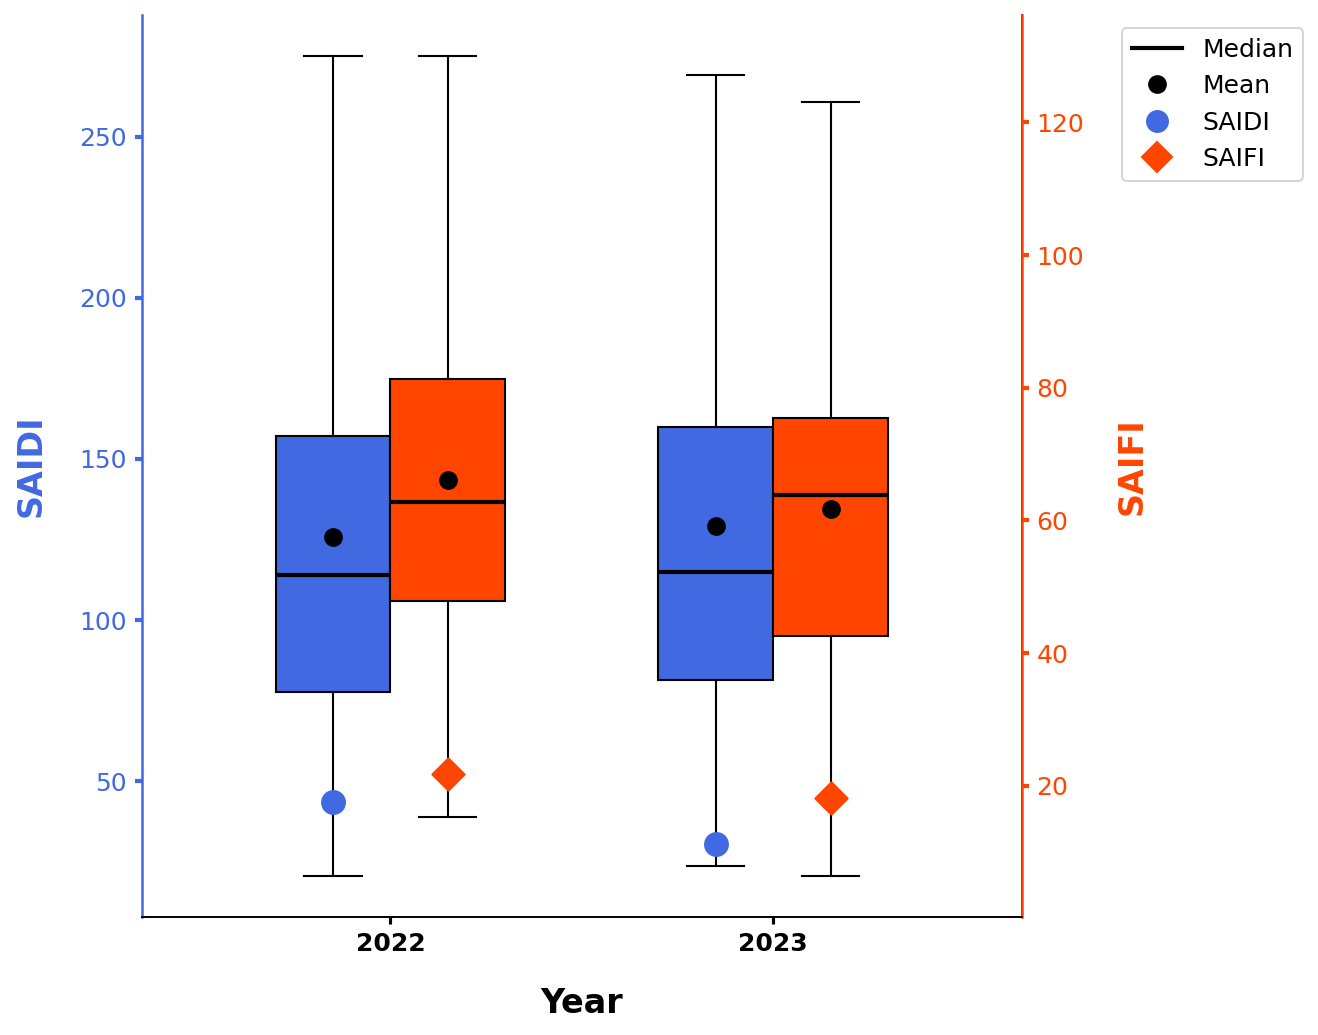

In [26]:
plot_saidi_saifi_dual_boxplot_with_custom_markers(
    saidi_saifi_merged,
    dpi = 150, 
    figsize=(9, 7),
    years=(2022, 2023),
    saidi_marker_values=[43.7, 30.7],
    saifi_marker_values=[21.8, 18.2],
    saidi_color="royalblue",
    saifi_color="orangered",
    show_means=True, 
    # mean_marker='s',
    mean_marker='o',
    mean_markerfacecolor='k',
    mean_markeredgecolor='k',
    save_path=PLOTS_DIR / 'supplementary/saidi_saifi_combined_boxplot_with_legend_v1.png'
)
